#  Phase 3: Transformer-Based Classification
Learn how transformers work and when they're worth the cost
## Import

In [3]:
# to access Google Drive files in Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

# Define the path (ensure the 'My Drive' part is exact)
path = "/content/drive/My Drive/Colab_Notebooks/ML"

# Change the current working directory
os.chdir(path)

# Verify you are in the right place
print("Current Directory:", os.getcwd())
print("Files in this folder:", os.listdir())

Current Directory: /content/drive/My Drive/Colab_Notebooks/ML
Files in this folder: ['customer_support_clean.csv', 'label_encoder.pkl']


In [1]:

# !pip install transformers datasets accelerate -q

import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

print(f" PyTorch version: {torch.__version__}")
print(f" Transformers installed")
print(f" CUDA available: {torch.cuda.is_available()}")

 PyTorch version: 2.10.0+cu128
 Transformers installed
 CUDA available: True


## Load and prepare data


In [7]:
# Load original data
# df = pd.read_csv('../data/customer_support_clean.csv')
df = pd.read_csv('customer_support_clean.csv')
# label_encoder = joblib.load('../models/label_encoder.pkl')
label_encoder = joblib.load('label_encoder.pkl')
# Encode labels
df['label'] = label_encoder.transform(df['category'])

print(f" Dataset loaded: {len(df):,} samples")
print(f" Number of classes: {df['label'].nunique()}")

# Create train/val/test splits (same as before)
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

print(f"\n Splits:")
print(f"  Train: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_df):,} ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df):,} ({len(test_df)/len(df)*100:.1f}%)")

# Show sample
print(f"\n Sample:")
print(train_df[['instruction', 'category', 'label']].head(3))

 Dataset loaded: 26,872 samples
 Number of classes: 11

 Splits:
  Train: 18,810 (70.0%)
  Val:   4,031 (15.0%)
  Test:  4,031 (15.0%)

 Sample:
                                             instruction  category  label
25086       seeing order {{Order Number}} current status     ORDER      6
3234   I do not know what to do to see the withdrawal...    CANCEL      1
13798  can you show me how soon can I expect my purch...  DELIVERY      3


## Convert to Hugging Face Dataset format
Hugging Face works with Dataset objects, not pandas


In [8]:

# Select only needed columns
train_data = train_df[['instruction', 'label']].rename(columns={'instruction': 'text'})
val_data = val_df[['instruction', 'label']].rename(columns={'instruction': 'text'})
test_data = test_df[['instruction', 'label']].rename(columns={'instruction': 'text'})

# Convert to HF Dataset
train_dataset = Dataset.from_pandas(train_data, preserve_index=False)
val_dataset = Dataset.from_pandas(val_data, preserve_index=False)
test_dataset = Dataset.from_pandas(test_data, preserve_index=False)

# Combine into DatasetDict
dataset = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

print(" Converted to Hugging Face Dataset format")
print(dataset)

 Converted to Hugging Face Dataset format
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 18810
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 4031
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 4031
    })
})


## Explore BERT tokenization
Key differences from our LSTM tokenizer:
- BERT uses WordPiece (subword tokenization)
- Handles unknown words by breaking into pieces
- Adds [CLS] at start, [SEP] at end

In [9]:
print(" UNDERSTANDING BERT TOKENIZATION")
print("=" * 60)

# Load BERT tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Example text
sample_text = train_df['instruction'].iloc[0]
print(f"Original text:\n{sample_text}\n")

# Tokenize
tokens = tokenizer.tokenize(sample_text)
print(f"BERT tokens:\n{tokens}\n")

# Convert to IDs
token_ids = tokenizer.encode(sample_text)
print(f"Token IDs:\n{token_ids}\n")

# Special tokens
print(f"Special tokens:")
print(f"  [CLS] token: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})")
print(f"  [SEP] token: {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})")
print(f"  [PAD] token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")

print(f"  - Vocabulary size: {tokenizer.vocab_size:,}")

 UNDERSTANDING BERT TOKENIZATION


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Original text:
seeing order {{Order Number}} current status

BERT tokens:
['seeing', 'order', '{', '{', 'order', 'number', '}', '}', 'current', 'status']

Token IDs:
[101, 3773, 2344, 1063, 1063, 2344, 2193, 1065, 1065, 2783, 3570, 102]

Special tokens:
  [CLS] token: [CLS] (ID: 101)
  [SEP] token: [SEP] (ID: 102)
  [PAD] token: [PAD] (ID: 0)
  - Vocabulary size: 30,522


## Tokenize entire dataset


In [10]:
def tokenize_function(examples):
    """Tokenize texts for BERT"""
    return tokenizer(
        examples['text'],
        truncation=True,
        padding=False,  # We'll pad dynamically in batches
        max_length=128  # Maximum sequence length
    )

print(" Tokenizing entire dataset...")
tokenized_dataset = dataset.map(
    tokenize_function, 
    batched=True,
    desc="Tokenizing"
)

print(" Tokenization complete!")
print(tokenized_dataset)

# Look at a tokenized example
print("\n Tokenized example:")
print(f"Original: {dataset['train'][0]['text']}")
print(f"Token IDs: {tokenized_dataset['train'][0]['input_ids'][:20]}")
print(f"Length: {len(tokenized_dataset['train'][0]['input_ids'])} tokens")

 Tokenizing entire dataset...


Tokenizing:   0%|          | 0/18810 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/4031 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/4031 [00:00<?, ? examples/s]

 Tokenization complete!
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 18810
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4031
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4031
    })
})

 Tokenized example:
Original: seeing order {{Order Number}} current status
Token IDs: [101, 3773, 2344, 1063, 1063, 2344, 2193, 1065, 1065, 2783, 3570, 102]
Length: 12 tokens


## Experiment 3A - Fine-tune BERT


In [11]:
# Load pre-trained BERT for classification
num_labels = len(label_encoder.classes_)

print(f"  LOADING BERT MODEL")
print("=" * 60)
print(f"Model: {model_name}")
print(f"Task: Sequence Classification")
print(f"Number of labels: {num_labels}")

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    problem_type="single_label_classification"
)

# Check model size
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Model statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Size: ~{total_params * 4 / 1024**2:.1f} MB (FP32)")

  LOADING BERT MODEL
Model: bert-base-uncased
Task: Sequence Classification
Number of labels: 11


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Model statistics:
  Total parameters: 109,490,699
  Trainable parameters: 109,490,699
  Size: ~417.7 MB (FP32)


In [12]:
# Define training arguments
output_dir = "../models/bert_finetuned"

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,                    # BERT learns fast, 3 epochs enough
    per_device_train_batch_size=16,        # Smaller batch due to memory
    per_device_eval_batch_size=32,
    learning_rate=2e-5,                    # Lower LR for fine-tuning
    weight_decay=0.01,
    eval_strategy="epoch",                 # Evaluate after each epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="../experiments/bert_logs",
    logging_steps=50,
    warmup_steps=500,                      # Gradual learning rate warmup
    report_to="none",                      # Don't send to wandb/tensorboard
    fp16=torch.cuda.is_available(),        # Use mixed precision if GPU available
)

print(" Training configuration set")
print(f" Training for {training_args.num_train_epochs} epochs")
print(f" Batch size: {training_args.per_device_train_batch_size}")
print(f" Learning rate: {training_args.learning_rate}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


 Training configuration set
 Training for 3 epochs
 Batch size: 16
 Learning rate: 2e-05


In [13]:
# Define metrics
def compute_metrics(eval_pred):
    """Compute accuracy and F1 during training"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'f1': f1_macro,
        'f1_weighted': f1_weighted
    }

In [14]:
# Create Trainer and start fine-tuning
print(" EXPERIMENT 3A: BERT Fine-tuning")
print("=" * 60)

# Data collator (handles padding)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print(" Starting fine-tuning...")
print("This may take a couple of minutes depending on your hardware\n")

start_time = time.time()

# Train!
train_result = trainer.train()

training_time_bert = time.time() - start_time

print(f"\n Training completed in {training_time_bert/60:.1f} minutes")
print(f" Final training loss: {train_result.training_loss:.4f}")

# Save the model
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)
print(f" Model saved to: {output_dir}")

 EXPERIMENT 3A: BERT Fine-tuning
 Starting fine-tuning...
This may take a couple of minutes depending on your hardware



Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 Weighted
1,0.003021,0.007981,0.998512,0.998503,0.998511
2,0.010303,0.007563,0.998760,0.998859,0.998759
3,0.000737,0.005342,0.999008,0.999214,0.999007


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


 Training completed in 6.7 minutes
 Final training loss: 0.1718


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Model saved to: ../models/bert_finetuned


In [15]:
# Evaluate on validation set
print("\n VALIDATION RESULTS")
print("=" * 60)

eval_results = trainer.evaluate()

for key, value in eval_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")

bert_f1 = eval_results['eval_f1']

print(f"  BERT:        {bert_f1*100:.1f}% F1")



 VALIDATION RESULTS


eval_loss: 0.0053
eval_accuracy: 0.9990
eval_f1: 0.9992
eval_f1_weighted: 0.9990
eval_runtime: 3.1851
eval_samples_per_second: 1265.5660
eval_steps_per_second: 39.5590
epoch: 3.0000
  BERT:        99.9% F1


eval_loss: 0.0023
eval_accuracy: 0.9993
eval_f1: 0.9995
eval_f1_weighted: 0.9993
eval_runtime: 2.0640
eval_samples_per_second: 1953.0320
eval_steps_per_second: 61.0470
epoch: 3.0000
  BERT:        99.9% F1

## Experiment 3B - DistilBERT (Efficient Version)

In [16]:
# Try DistilBERT (smaller, faster)
print(" EXPERIMENT 3B: DistilBERT (Efficient Version)")
print("=" * 60)

distilbert_name = "distilbert-base-uncased"

# Load tokenizer and model
distil_tokenizer = AutoTokenizer.from_pretrained(distilbert_name)
distil_model = AutoModelForSequenceClassification.from_pretrained(
    distilbert_name,
    num_labels=num_labels
)

# Model size comparison
bert_params = total_params
distil_params = sum(p.numel() for p in distil_model.parameters())

print(f" Model Comparison:")
print(f"  BERT parameters:      {bert_params:,} (~110M)")
print(f"  DistilBERT parameters: {distil_params:,} (~66M)")
print(f"  Reduction: {(1 - distil_params/bert_params)*100:.1f}%")

 EXPERIMENT 3B: DistilBERT (Efficient Version)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Model Comparison:
  BERT parameters:      109,490,699 (~110M)
  DistilBERT parameters: 66,961,931 (~66M)
  Reduction: 38.8%


In [17]:
# Tokenize for DistilBERT
def tokenize_distil(examples):
    return distil_tokenizer(
        examples['text'],
        truncation=True,
        padding=False,
        max_length=128
    )

print(" Tokenizing for DistilBERT...")
distil_tokenized = dataset.map(
    tokenize_distil,
    batched=True,
    desc="Tokenizing"
)
print(" Tokenization is Done!")

 Tokenizing for DistilBERT...


Tokenizing:   0%|          | 0/18810 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/4031 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/4031 [00:00<?, ? examples/s]

 Tokenization is Done!


In [19]:
# Train DistilBERT
distil_output_dir = "../models/distilbert_finetuned"

distil_training_args = TrainingArguments(
    output_dir=distil_output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

distil_trainer = Trainer(
    model=distil_model,
    args=distil_training_args,
    train_dataset=distil_tokenized['train'],
    eval_dataset=distil_tokenized['validation'],
    data_collator=DataCollatorWithPadding(tokenizer=distil_tokenizer),
    compute_metrics=compute_metrics,
)

print(" Training DistilBERT...")
start_time = time.time()

distil_result = distil_trainer.train()

distil_training_time = time.time() - start_time

print(f"\n Training completed in {distil_training_time/60:.1f} minutes")

# Evaluate
distil_eval = distil_trainer.evaluate()
distilbert_f1 = distil_eval['eval_f1']

print(f"\n DistilBERT F1: {distilbert_f1:.4f}")

# Save
distil_trainer.save_model(distil_output_dir)
distil_tokenizer.save_pretrained(distil_output_dir)

 Training DistilBERT...


Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 Weighted
1,0.009137,0.005256,0.998512,0.998261,0.998511
2,0.008057,0.001565,0.999256,0.999366,0.999256
3,0.000531,0.001532,0.999752,0.999873,0.999752


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



 Training completed in 2.8 minutes



 DistilBERT F1: 0.9999


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../models/distilbert_finetuned/tokenizer_config.json',
 '../models/distilbert_finetuned/tokenizer.json')

## Complete Comparison


In [21]:
# Compare ALL models so far
results_complete = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'GloVe + Logistic Regression',
        'GloVe + Neural Network',
        'Bidirectional LSTM',
        'BERT (base)',
        'DistilBERT'
    ],
    'F1 (Macro)': [
        0.9955,     # From Phase 1
        0.9111,     # From Phase 2
        0.9426,     # From Phase 2 
        0.9942,     # From Phase 2 
        bert_f1,
        distilbert_f1
    ],
    'Parameters': [
        '53K',
        '~560',
        '~15.5K',
        '~1.13M',
        '110M',
        '67M'
    ],
    'Training Time (sec)': [
        2,  
        5,
        22,  # From Phase 2
        1461,  # From Phase 2
        training_time_bert,
        distil_training_time
    ],
})

print(" COMPLETE MODEL COMPARISON (All Phases)")
print("=" * 80)
print(results_complete.to_string(index=False))

# Save
# results_complete.to_csv('../experiments/complete_classification_results.csv', index=False)
results_complete.to_csv('complete_classification_results.csv', index=False)
print("\n Saved to: experiments/complete_classification_results.csv")

 COMPLETE MODEL COMPARISON (All Phases)
                       Model  F1 (Macro) Parameters  Training Time (sec)
TF-IDF + Logistic Regression    0.995500        53K             2.000000
 GloVe + Logistic Regression    0.911100       ~560             5.000000
      GloVe + Neural Network    0.942600     ~15.5K            22.000000
          Bidirectional LSTM    0.994200     ~1.13M          1461.000000
                 BERT (base)    0.999214       110M           400.859767
                  DistilBERT    0.999873        67M           166.463498

 Saved to: experiments/complete_classification_results.csv


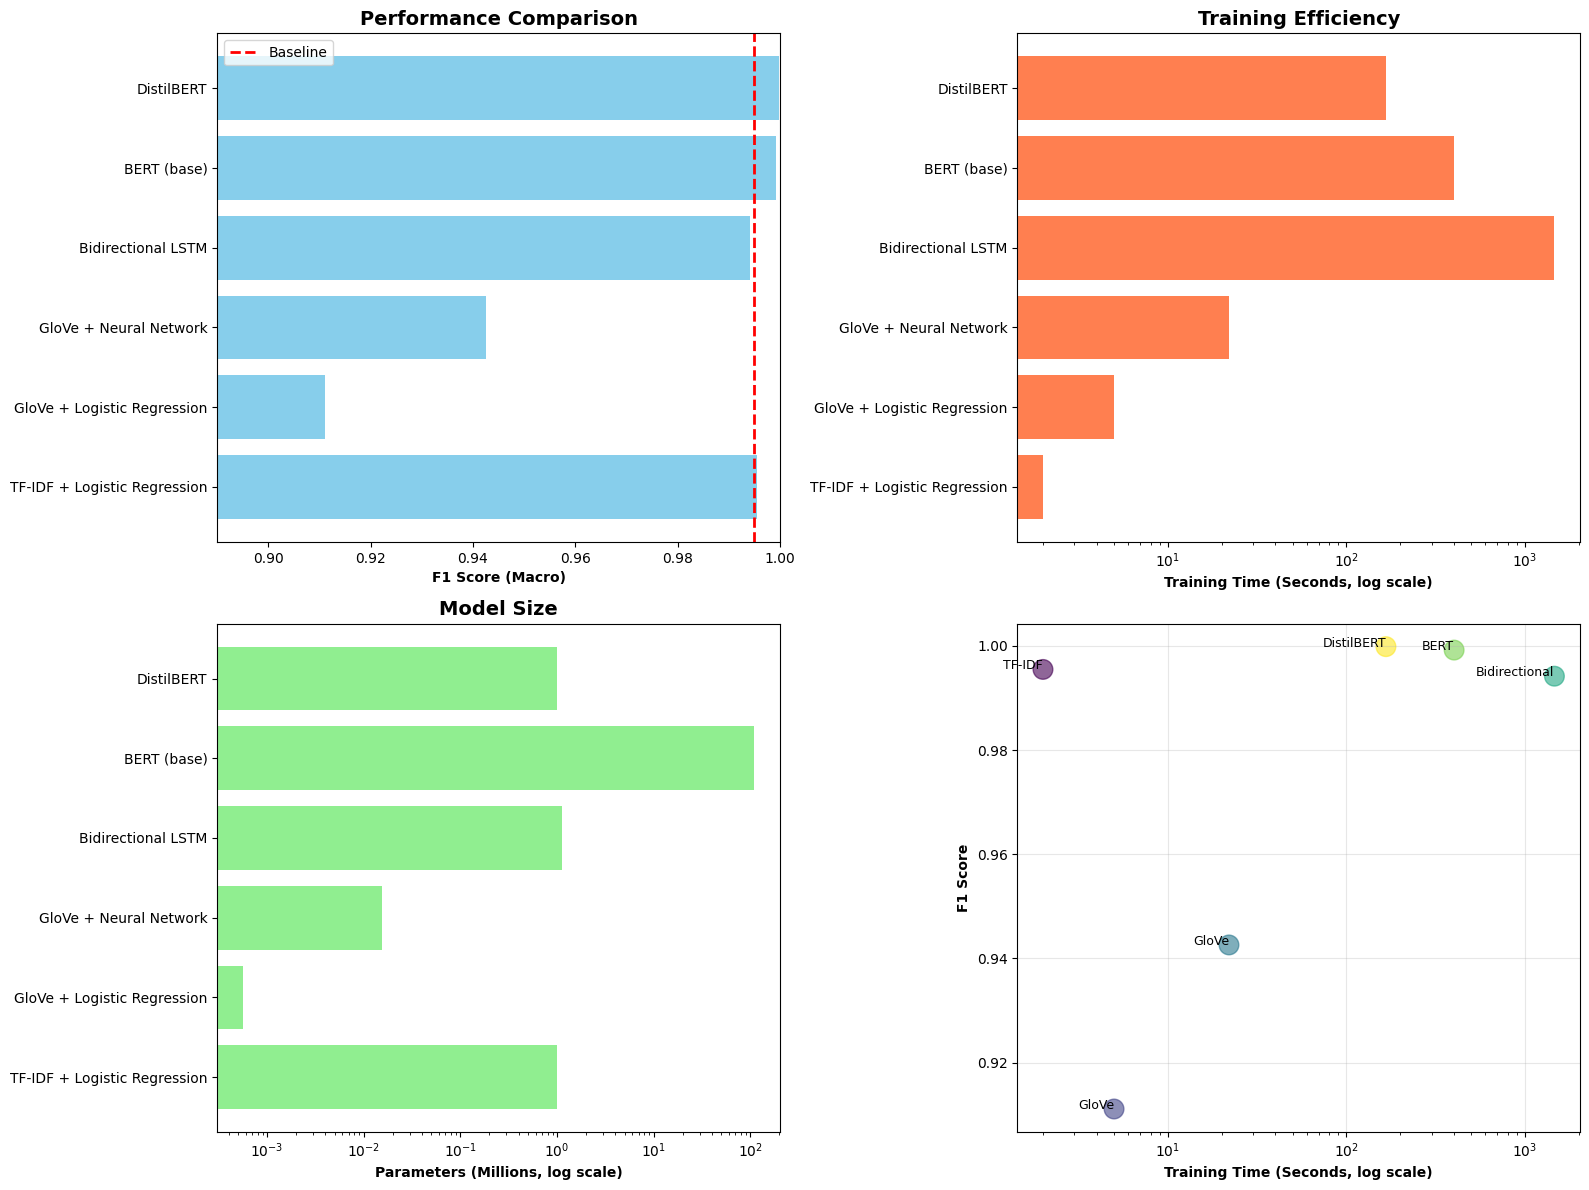

 Visualization saved to: experiments/complete_Classification_comparison.png


In [23]:
# Visualize the complete picture
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. F1 Score comparison
axes[0, 0].barh(results_complete['Model'], results_complete['F1 (Macro)'], color='skyblue')
axes[0, 0].set_xlabel('F1 Score (Macro)', fontweight='bold')
axes[0, 0].set_title('Performance Comparison', fontsize=14, fontweight='bold')
axes[0, 0].axvline(x=0.995, color='r', linestyle='--', linewidth=2, label='Baseline')
axes[0, 0].set_xlim([0.89, 1.0])
axes[0, 0].legend()

# 2. Training time
train_times = results_complete['Training Time (sec)'].values
axes[0, 1].barh(results_complete['Model'], train_times, color='coral')
axes[0, 1].set_xlabel('Training Time (Seconds, log scale)', fontweight='bold')
axes[0, 1].set_title('Training Efficiency', fontsize=14, fontweight='bold')
axes[0, 1].set_xscale('log')

# 3. Parameters
param_map = {
    '500K': 0.5,
    '~560': 0.00056,
    '~15.5K': 0.0155,
    '~1.13M': 1.13,
    '110M': 110,
    '66M': 66
}
param_values = [param_map.get(p, 1) for p in results_complete['Parameters']]

axes[1, 0].barh(results_complete['Model'], param_values, color='lightgreen')
axes[1, 0].set_xlabel('Parameters (Millions, log scale)', fontweight='bold')
axes[1, 0].set_title('Model Size', fontsize=14, fontweight='bold')
axes[1, 0].set_xscale('log')

# 4. Cost-benefit scatter
axes[1, 1].scatter(train_times, results_complete['F1 (Macro)'], s=200, alpha=0.6, c=range(len(results_complete)), cmap='viridis')
for i, model in enumerate(results_complete['Model']):
    axes[1, 1].annotate(model.split()[0], 
                       (train_times[i], results_complete['F1 (Macro)'].iloc[i]),
                       fontsize=9, ha='right')
axes[1, 1].set_xlabel('Training Time (Seconds, log scale)', fontweight='bold')
axes[1, 1].set_ylabel('F1 Score', fontweight='bold')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('../experiments/complete_Classification_comparison.png', dpi=150, bbox_inches='tight')
plt.savefig('complete_Classification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Visualization saved to: experiments/complete_Classification_comparison.png")

## Test with Real Examples

In [ ]:

# Interactive prediction with BERT
from transformers import pipeline

# Create classifier
classifier = pipeline(
    "text-classification",
    model=output_dir,
    tokenizer=output_dir,
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=True
)


def predict_with_bert(text):
    """Predict category using BERT"""
    results = classifier(text)[0]

    # Sort by score
    results = sorted(results, key=lambda x: x['score'], reverse=True)

    top = [results]
   
    

    
    print(f"Query: '{text}'")
    print(f"\n Top 3 Predictions:")
    for pred in top:
        label_idx = int(pred['label'].split('_')[-1])
        category = label_encoder.inverse_transform([label_idx])[0]
        print(f"  {category}: {pred['score']:.2%}")
    print("=" * 60)

# Test
test_queries = [
    "I want to change my shipping address",
    "How do I cancel my subscription?",
    "My payment failed, what should I do?",
]

print(" TESTING BERT PREDICTIONS")
print("=" * 60)
for query in test_queries:
    predict_with_bert(query)
    print()